# Menguji Robustness

## 1. Import module dan library yang dibutuhkan

In [1]:
import sys  # Library untuk mengatur path Python
sys.path.append('..')  
# Menambahkan path ke folder parent agar bisa import module dari src/

from sklearn.metrics import classification_report, accuracy_score  
# classification_report → menampilkan precision, recall, f1-score
# accuracy_score → menghitung akurasi model

from src.utils import load_objek  
# Fungsi untuk load file pickle (model & data)

## 2. Logika code

### 2.1 Load Data uji dan model final

In [2]:
data = load_objek('../data/processed/data_vektor.pkl')  
# Memuat data hasil TF-IDF (fitur sudah dalam bentuk vektor)

final_model = load_objek('../models/stacking_final_tuning.pkl')  
# Memuat model stacking yang sudah dilatih sebelumnya

default_model = load_objek('../models/stacking_final_default.pkl')


y_test = data['y_test']  
# Label asli (ground truth)

X_test_clean = data['X_test_clean']  
# Data uji dalam kondisi bersih (ideal)

X_test_noisy = data['X_test_noisy']  
# Data uji dalam kondisi kotor/noisy (simulasi dunia nyata)

### 2.2 Pengujian Skenario 1: Data Bersih (Ideal Condition)

In [3]:
print("=== PENGUJIAN KONDISI IDEAL (DATA BERSIH) ===")

pred_clean = final_model.predict(X_test_clean)  
# Model melakukan prediksi pada data test bersih

print(f"Akurasi: {accuracy_score(y_test, pred_clean):.4f}")  
# Menghitung akurasi (jumlah prediksi benar / total data)

print(
    classification_report(
        y_test, 
        pred_clean, 
        target_names=['Fakta (0)', 'Hoaks (1)']
    )
)
# Menampilkan metrik:
# - Precision → seberapa tepat prediksi positif
# - Recall → seberapa banyak data positif yang berhasil ditangkap
# - F1-score → keseimbangan precision & recall


=== PENGUJIAN KONDISI IDEAL (DATA BERSIH) ===
Akurasi: 0.8336
              precision    recall  f1-score   support

   Fakta (0)       0.67      0.34      0.45       154
   Hoaks (1)       0.85      0.96      0.90       609

    accuracy                           0.83       763
   macro avg       0.76      0.65      0.68       763
weighted avg       0.82      0.83      0.81       763



### 2.3 Pengujian Skenario 2: Data Kotor (Robustness Test)

In [4]:
print("\n=== PENGUJIAN ROBUSTNESS (DATA KOTOR / NOISY) ===")

pred_noisy = final_model.predict(X_test_noisy)  
# Model melakukan prediksi pada data noisy (lebih realistis)

print(f"Akurasi: {accuracy_score(y_test, pred_noisy):.4f}")  
# Mengukur performa model pada kondisi data yang tidak ideal

print(
    classification_report(
        y_test, 
        pred_noisy, 
        target_names=['Fakta (0)', 'Hoaks (1)']
    )
)
# Digunakan untuk melihat:
# apakah performa model turun drastis atau tetap stabil


=== PENGUJIAN ROBUSTNESS (DATA KOTOR / NOISY) ===
Akurasi: 0.8388
              precision    recall  f1-score   support

   Fakta (0)       0.76      0.29      0.42       154
   Hoaks (1)       0.85      0.98      0.91       609

    accuracy                           0.84       763
   macro avg       0.80      0.63      0.66       763
weighted avg       0.83      0.84      0.81       763



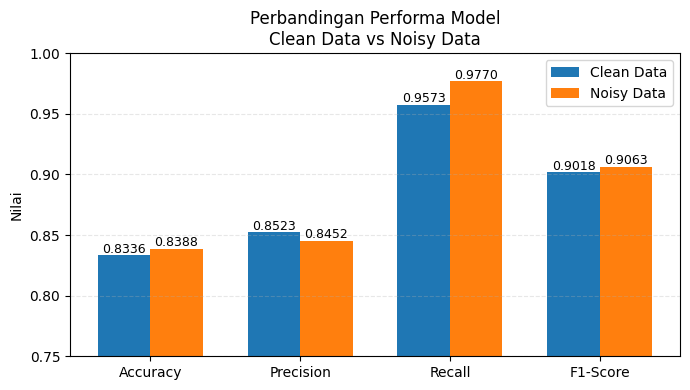

In [5]:
# ============================================================
# PERBANDINGAN PERFORMA: CLEAN DATA vs NOISY DATA
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ============================================================
# 1. PREDIKSI MODEL (PAKAI MODEL TERBAIK)
# ============================================================

# Clean data
y_pred_clean = final_model.predict(X_test_clean)

# Noisy data
y_pred_noisy = final_model.predict(X_test_noisy)

# ============================================================
# 2. HITUNG METRIK
# ============================================================

def get_metrics(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred, zero_division=0),
        f1_score(y_true, y_pred, zero_division=0)
    ]

clean_scores = get_metrics(y_test, y_pred_clean)
noisy_scores = get_metrics(y_test, y_pred_noisy)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# ============================================================
# 3. BAR CHART (PERBANDINGAN)
# ============================================================

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(7, 4))

bars1 = plt.bar(x - width/2, clean_scores, width, label='Clean Data')
bars2 = plt.bar(x + width/2, noisy_scores, width, label='Noisy Data')

# ============================================================
# 4. LABEL ANGKA
# ============================================================

def add_label(bars):
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.002,
            f'{h:.4f}',
            ha='center',
            fontsize=9
        )

add_label(bars1)
add_label(bars2)

# ============================================================
# 5. TAMPILAN
# ============================================================

plt.xticks(x, metrics)
plt.ylabel('Nilai')
plt.title('Perbandingan Performa Model\nClean Data vs Noisy Data')

plt.ylim(0.75, 1.00)  # sesuaikan kalau perlu
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("../gambar/robustness_clean_vs_noisy.png", dpi=300, bbox_inches='tight')
plt.show()